<a href="https://colab.research.google.com/github/piresthiago10/mvp_quarta_sprint_backend/blob/main/gen_z_Mental_wellness_and_digital_lifestyle_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gen Z Mental Wellness & Digital Lifestyle Analysis

O [Gen Z Mental Wellness & Digital Lifestyle Analysis Dataset](https://www.kaggle.com/datasets/hammadansari7/gen-z-mental-wellness-and-digital-lifestyle-patterns) é um conjunto de dados sintético que modela a relação entre hábitos digitais, estilo de vida e indicadores de bem-estar psicológico em jovens de 18 a 26 anos. Ele simula correlações realistas entre uso de telas, sono, exercícios e aspectos emocionais, sendo voltado para análise e modelagem de dados. Os indicadores psicológicos são apenas simulados e não possuem validade clínica.

### Colunas do dataset:

- Age: Idade (18–26)
- Gender: Gênero (Male, Female, Non-binary)
- Country: País de residência
- Student_Working_Status: Situação (Student, Working, Both)
- Daily_Social_Media_Hours: Média diária de uso de redes sociais
- Screen_Time_Hours: Tempo total diário de tela
- Night_Scrolling_Frequency: Frequência de uso do celular à noite
- Online_Gaming_Hours: Horas diárias de jogos online
- Content_Type_Preference: Tipo principal de conteúdo consumido
- Exercise_Frequency_per_Week: Frequência de exercícios por semana
- Daily_Sleep_Hours: Horas de sono por dia
- Caffeine_Intake_Cups: Consumo diário de cafeína (xícaras)
- Study_Work_Hours_per_Day: Horas diárias de estudo/trabalho
- Overthinking_Score: Nível de overthinking (1–10)
- Anxiety_Score: Nível de ansiedade (1–10)
- Mood_Stability_Score: Estabilidade de humor (1–10)
- Social_Comparison_Index: Tendência à comparação social (1–10)
- Sleep_Quality_Score: Qualidade do sono (1–10)
- Motivation_Level: Nível de motivação (1–10)
- Emotional_Fatigue_Score: Fadiga emocional (1–10)
- Wellbeing_Index: Índice composto de bem-estar (variável alvo contínua)
- Burnout_Risk: Risco de burnout (Low, Medium, High)

O objetivo é prever se um indivíduo da geração z tem risco de burnout em relação a suas características comportamentais e rotineiras.

# Configuração do Ambiente

In [22]:
import os
import numpy as np
import pandas as pd
import cloudpickle

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.preprocessing import FunctionTransformer
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.compose import ColumnTransformer


import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Carga do Dataset


In [23]:
df_original = pd.read_csv("https://raw.githubusercontent.com/piresthiago10/mvp_quarta_sprint_backend/refs/heads/main/app/machine_learning/data/genz_mental_wellness_synthetic_dataset.csv", sep = ',')

In [24]:
df_original.shape

(10000, 22)

In [25]:
df_original.head()

,Age,Gender,Country,Student_Working_Status,Daily_Social_Media_Hours,Screen_Time_Hours,Night_Scrolling_Frequency,Online_Gaming_Hours,Content_Type_Preference,Exercise_Frequency_per_Week,Daily_Sleep_Hours,Caffeine_Intake_Cups,Study_Work_Hours_per_Day,Overthinking_Score,Anxiety_Score,Mood_Stability_Score,Social_Comparison_Index,Sleep_Quality_Score,Motivation_Level,Emotional_Fatigue_Score,Wellbeing_Index,Burnout_Risk
0,24,Male,Canada,Working,4.81,6.93,2.61,2.07,News,5.41,6.84,1.52,11.42,4.95,4.13,5.74,4.67,6.27,6.13,6.45,4.28,Medium
1,21,Male,USA,Student,4.16,7.94,1.85,3.58,Gaming,3.41,7.88,2.23,6.98,5.91,3.63,5.75,5.38,7.37,6.27,3.74,5.23,Medium
2,25,Male,Pakistan,Student,3.07,7.45,2.96,2.85,Entertainment,3.40,6.39,0.53,7.79,4.06,5.67,6.03,2.41,6.48,4.82,6.69,3.72,High
3,22,Female,Pakistan,Student,4.41,7.34,4.51,3.37,Educational,2.19,7.92,0.58,6.61,6.10,4.78,4.85,5.86,7.27,5.17,5.96,3.97,High
4,24,Male,Pakistan,Student,2.97,5.76,2.36,1.77,Educational,4.93,5.97,1.64,4.81,5.22,4.23,5.05,5.54,6.34,5.72,2.22,4.63,Medium


In [26]:
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          10000 non-null  int64  
 1   Gender                       10000 non-null  object 
 2   Country                      10000 non-null  object 
 3   Student_Working_Status       10000 non-null  object 
 4   Daily_Social_Media_Hours     10000 non-null  float64
 5   Screen_Time_Hours            10000 non-null  float64
 6   Night_Scrolling_Frequency    10000 non-null  float64
 7   Online_Gaming_Hours          10000 non-null  float64
 8   Content_Type_Preference      10000 non-null  object 
 9   Exercise_Frequency_per_Week  10000 non-null  float64
 10  Daily_Sleep_Hours            10000 non-null  float64
 11  Caffeine_Intake_Cups         10000 non-null  float64
 12  Study_Work_Hours_per_Day     10000 non-null  float64
 13  Overthinking_Scor

In [27]:
df_original = df_original.drop(columns=['Country'])

In [28]:
df_original.describe()

,Age,Daily_Social_Media_Hours,Screen_Time_Hours,Night_Scrolling_Frequency,Online_Gaming_Hours,Exercise_Frequency_per_Week,Daily_Sleep_Hours,Caffeine_Intake_Cups,Study_Work_Hours_per_Day,Overthinking_Score,Anxiety_Score,Mood_Stability_Score,Social_Comparison_Index,Sleep_Quality_Score,Motivation_Level,Emotional_Fatigue_Score,Wellbeing_Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,21.992900,4.005883,7.016991,2.986009,1.607241,2.994855,6.512031,1.505871,6.030983,5.001868,4.747556,5.161021,4.403556,6.514447,5.086132,5.582222,3.870213
std,2.589309,1.480509,1.792529,1.197035,1.300045,1.478248,1.194194,0.934069,1.975337,1.143179,1.305593,1.257055,1.336479,1.427806,1.308351,1.416558,1.238940
min,18.000000,0.500000,2.000000,0.000000,0.000000,0.000000,3.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.020000,1.000000,1.000000,1.000000
25%,20.000000,3.010000,5.810000,2.187500,0.470000,1.960000,5.710000,0.800000,4.700000,4.240000,3.840000,4.310000,3.470000,5.550000,4.200000,4.620000,3.020000
50%,22.000000,3.990000,7.000000,2.980000,1.460000,3.010000,6.520000,1.480000,6.030000,5.000000,4.740000,5.170000,4.400000,6.530000,5.080000,5.580000,3.870000
75%,24.000000,4.982500,8.210000,3.790000,2.500000,4.000000,7.320000,2.150000,7.340000,5.760000,5.630000,6.000000,5.320000,7.490000,5.950000,6.540000,4.700000
max,26.000000,10.000000,14.000000,7.000000,6.000000,7.000000,10.000000,6.000000,13.050000,9.510000,9.690000,10.000000,9.420000,10.000000,10.000000,10.000000,8.860000


In [29]:
print(df_original.isna().sum())

Age                            0
Gender                         0
Student_Working_Status         0
Daily_Social_Media_Hours       0
Screen_Time_Hours              0
Night_Scrolling_Frequency      0
Online_Gaming_Hours            0
Content_Type_Preference        0
Exercise_Frequency_per_Week    0
Daily_Sleep_Hours              0
Caffeine_Intake_Cups           0
Study_Work_Hours_per_Day       0
Overthinking_Score             0
Anxiety_Score                  0
Mood_Stability_Score           0
Social_Comparison_Index        0
Sleep_Quality_Score            0
Motivation_Level               0
Emotional_Fatigue_Score        0
Wellbeing_Index                0
Burnout_Risk                   0
dtype: int64


In [30]:
df_original.nunique()

,0
Age,9
Gender,3
Student_Working_Status,3
Daily_Social_Media_Hours,755
Screen_Time_Hours,933
Night_Scrolling_Frequency,629
Online_Gaming_Hours,551
Content_Type_Preference,5
Exercise_Frequency_per_Week,682
Daily_Sleep_Hours,650


## Analisando variáveis categoricas

In [31]:
df_original.groupby(['Gender']).size()

,0
Gender,
Female,4481
Male,4547
Non-binary,972


In [32]:
df_original.groupby(['Student_Working_Status']).size()

,0
Student_Working_Status,
Both,973
Student,5971
Working,3056


In [33]:
df_original.groupby(['Content_Type_Preference']).size()

,0
Content_Type_Preference,
Educational,1961
Entertainment,1994
Gaming,2051
Lifestyle,1964
News,2030


In [34]:
df_original.groupby(['Burnout_Risk']).size()

,0
Burnout_Risk,
High,5388
Low,64
Medium,4548


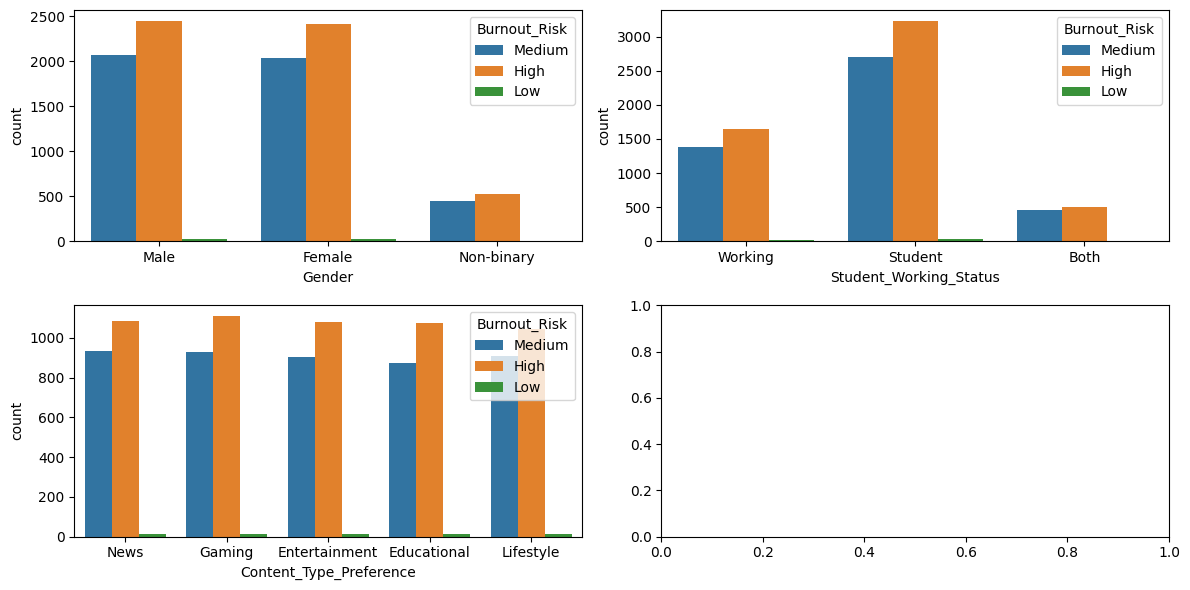

In [35]:
plt.rcParams["figure.figsize"] = [12.00, 6.00]
plt.rcParams["figure.autolayout"] = True
f, axes = plt.subplots(2, 2)
sns.countplot(data=df_original, x="Gender", hue="Burnout_Risk", ax=axes[0, 0])
sns.countplot(data=df_original, x="Student_Working_Status", hue="Burnout_Risk", ax=axes[0, 1])
sns.countplot(data=df_original, x="Content_Type_Preference", hue="Burnout_Risk", ax=axes[1, 0])
plt.tight_layout()
plt.show()

In [36]:
df_original['Sleep_Efficiency'] = df_original['Sleep_Quality_Score'] / (df_original['Daily_Sleep_Hours'] + 1)
df_original['Screen_Time_Ratio'] = df_original['Screen_Time_Hours'] / (24 - df_original['Daily_Sleep_Hours'])
df_original['Wellbeing_Balance'] = df_original['Motivation_Level'] - df_original['Emotional_Fatigue_Score']
df_original[['Sleep_Efficiency', 'Screen_Time_Ratio', 'Wellbeing_Balance']].head()

,Sleep_Efficiency,Screen_Time_Ratio,Wellbeing_Balance
0,0.799745,0.403846,-0.32
1,0.829955,0.492556,2.53
2,0.876861,0.423055,-1.87
3,0.815022,0.456468,-0.79
4,0.909613,0.319468,3.50


## Analisando as Variaveis Numéricas

In [37]:
variaveis_numericas = []
for i in df_original.columns[0:22].tolist():
        if df_original.dtypes[i] in ['int64', 'float64']:
            print(i, ':' , df_original.dtypes[i])
            variaveis_numericas.append(i)

Age : int64
Daily_Social_Media_Hours : float64
Screen_Time_Hours : float64
Night_Scrolling_Frequency : float64
Online_Gaming_Hours : float64
Exercise_Frequency_per_Week : float64
Daily_Sleep_Hours : float64
Caffeine_Intake_Cups : float64
Study_Work_Hours_per_Day : float64
Overthinking_Score : float64
Anxiety_Score : float64
Mood_Stability_Score : float64
Social_Comparison_Index : float64
Sleep_Quality_Score : float64
Motivation_Level : float64
Emotional_Fatigue_Score : float64
Wellbeing_Index : float64
Sleep_Efficiency : float64


In [38]:
df_copy = df_original.copy()

In [39]:
df_copy.head()

,Age,Gender,Student_Working_Status,Daily_Social_Media_Hours,Screen_Time_Hours,Night_Scrolling_Frequency,Online_Gaming_Hours,Content_Type_Preference,Exercise_Frequency_per_Week,Daily_Sleep_Hours,Caffeine_Intake_Cups,Study_Work_Hours_per_Day,Overthinking_Score,Anxiety_Score,Mood_Stability_Score,Social_Comparison_Index,Sleep_Quality_Score,Motivation_Level,Emotional_Fatigue_Score,Wellbeing_Index,Burnout_Risk,Sleep_Efficiency,Screen_Time_Ratio,Wellbeing_Balance
0,24,Male,Working,4.81,6.93,2.61,2.07,News,5.41,6.84,1.52,11.42,4.95,4.13,5.74,4.67,6.27,6.13,6.45,4.28,Medium,0.799745,0.403846,-0.32
1,21,Male,Student,4.16,7.94,1.85,3.58,Gaming,3.41,7.88,2.23,6.98,5.91,3.63,5.75,5.38,7.37,6.27,3.74,5.23,Medium,0.829955,0.492556,2.53
2,25,Male,Student,3.07,7.45,2.96,2.85,Entertainment,3.40,6.39,0.53,7.79,4.06,5.67,6.03,2.41,6.48,4.82,6.69,3.72,High,0.876861,0.423055,-1.87
3,22,Female,Student,4.41,7.34,4.51,3.37,Educational,2.19,7.92,0.58,6.61,6.10,4.78,4.85,5.86,7.27,5.17,5.96,3.97,High,0.815022,0.456468,-0.79
4,24,Male,Student,2.97,5.76,2.36,1.77,Educational,4.93,5.97,1.64,4.81,5.22,4.23,5.05,5.54,6.34,5.72,2.22,4.63,Medium,0.909613,0.319468,3.50


## Separação em conjunto de treino e conjunto de teste com holdout

In [40]:
categorical_features = [
    'Gender',
    'Student_Working_Status',
    'Content_Type_Preference'
    ]

numeric_features = [
    'Age',
    'Daily_Sleep_Hours',
    'Screen_Time_Hours',
    'Sleep_Efficiency',
    'Screen_Time_Ratio',
    'Wellbeing_Balance'
    ]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ])

test_size = 0.20 # tamanho do conjunto de teste
seed = 42 # semente aleatória

# Separação em conjuntos de treino e teste
df_data = df_copy.copy()
X = df_data.drop(['Burnout_Risk'], axis=1)
y = df_data['Burnout_Risk']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, shuffle=True, random_state=seed, stratify=y) # holdout com estratificação

# Parâmetros e partições da validação cruzada
scoring = 'accuracy'
num_particoes = 10
kfold = StratifiedKFold(n_splits=num_particoes, shuffle=True, random_state=seed) # validação cruzada com estratificação

# Modelagem e Inferência

## Criação e avaliação de modelos: linha base

LR: 0.865125 (0.013032)
KNN: 0.803125 (0.009831)
CART: 0.806875 (0.009654)
NB: 0.855750 (0.008646)
SVM: 0.860250 (0.010677)
Bagging: 0.856500 (0.012855)
RF: 0.862000 (0.010900)
ET: 0.849750 (0.009114)
Ada: 0.826375 (0.015954)
GB: 0.861625 (0.011687)
Voting: 0.864125 (0.012637)


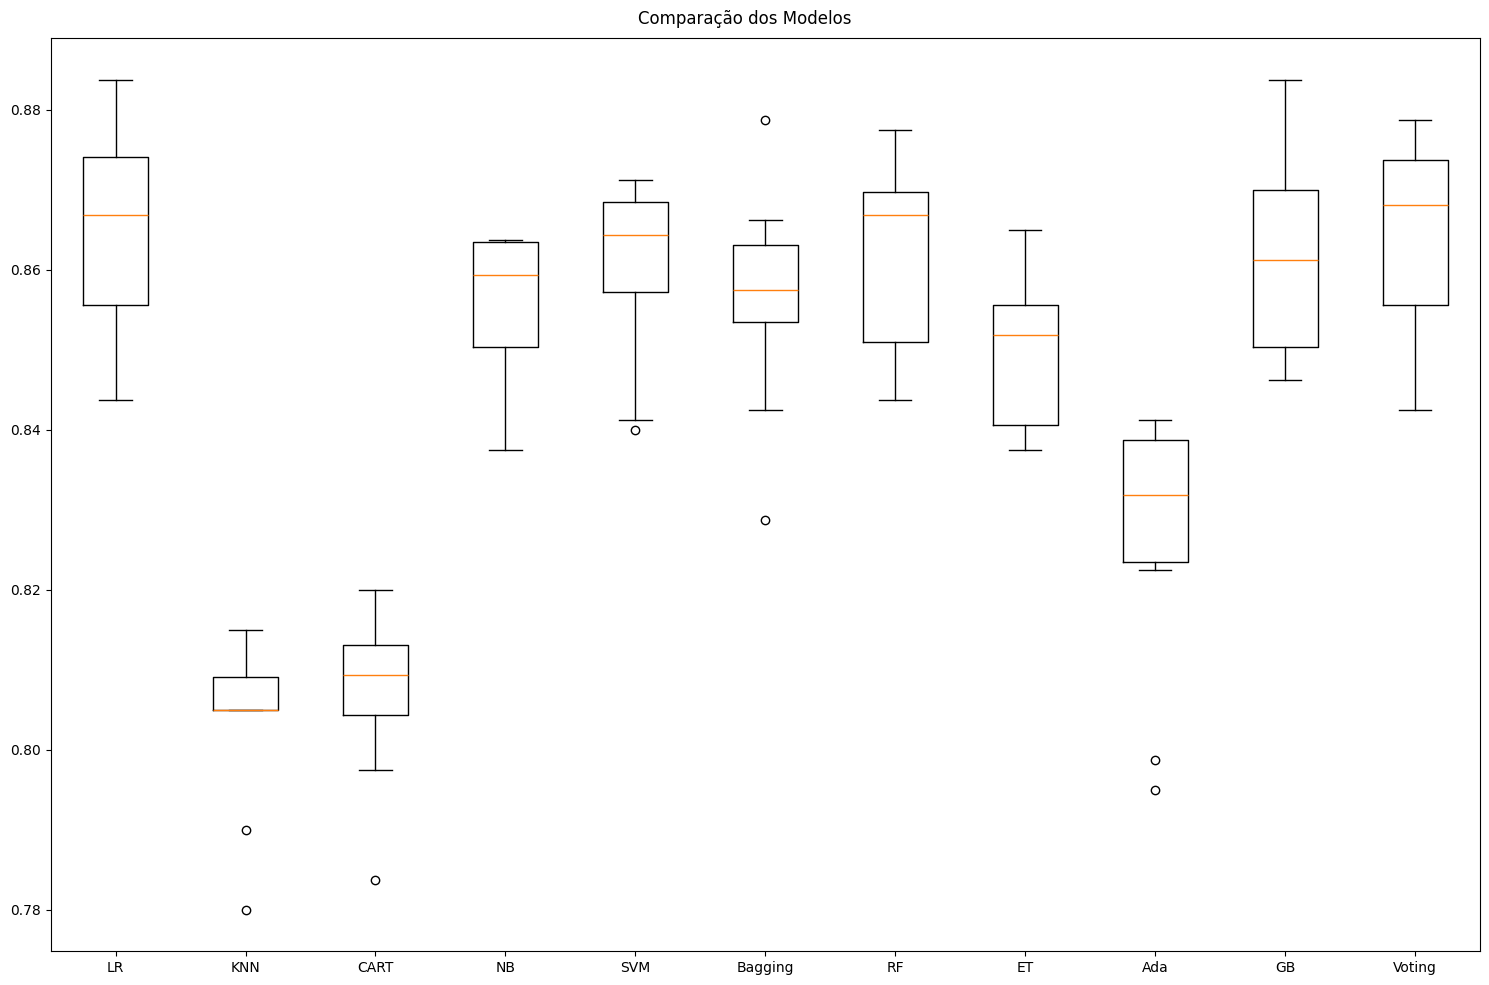

In [41]:
np.random.seed(42) # definindo uma semente global

# Lista que armazenará os modelos
models = []

# Criando os modelos e adicionando-os na lista de modelos
models.append(('LR', LogisticRegression(max_iter=200)))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC()))

# Definindo os parâmetros do classificador base para o BaggingClassifier
base = DecisionTreeClassifier()
num_trees = 100
max_features = 3

# Criando os modelos para o VotingClassifier
bases = []
model1 = LogisticRegression(max_iter=200)
bases.append(('logistic', model1))
model2 = DecisionTreeClassifier()
bases.append(('cart', model2))
model3 = SVC()
bases.append(('svm', model3))

# Criando os ensembles e adicionando-os na lista de modelos
models.append(('Bagging', BaggingClassifier(estimator=base, n_estimators=num_trees)))
models.append(('RF', RandomForestClassifier(n_estimators=num_trees, max_features=max_features)))
models.append(('ET', ExtraTreesClassifier(n_estimators=num_trees, max_features=max_features)))
models.append(('Ada', AdaBoostClassifier(n_estimators=num_trees)))
models.append(('GB', GradientBoostingClassifier(n_estimators=num_trees)))
models.append(('Voting', VotingClassifier(bases)))

results = []
names = []

for name, model in models:
    train_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Agora o cross_val_score recebe o PIPELINE, não o modelo isolado
    cv_results = cross_val_score(train_pipeline, X_train, y_train, cv=kfold, scoring=scoring)

    results.append(cv_results)
    names.append(name)

    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

# Boxplot de comparação dos modelos
fig = plt.figure(figsize=(15,10))
fig.suptitle('Comparação dos Modelos')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

## Criação e avaliação de modelos: dados padronizados e normalizados

LR: 0.865125 (0.013032)
KNN: 0.803125 (0.009831)
CART: 0.806875 (0.009654)
NB: 0.855750 (0.008646)
SVM: 0.860250 (0.010677)
Bagging: 0.856500 (0.012855)
RF: 0.862000 (0.010900)
ET: 0.849750 (0.009114)
Ada: 0.826375 (0.015954)
GB: 0.861625 (0.011687)
Voting: 0.864125 (0.012637)


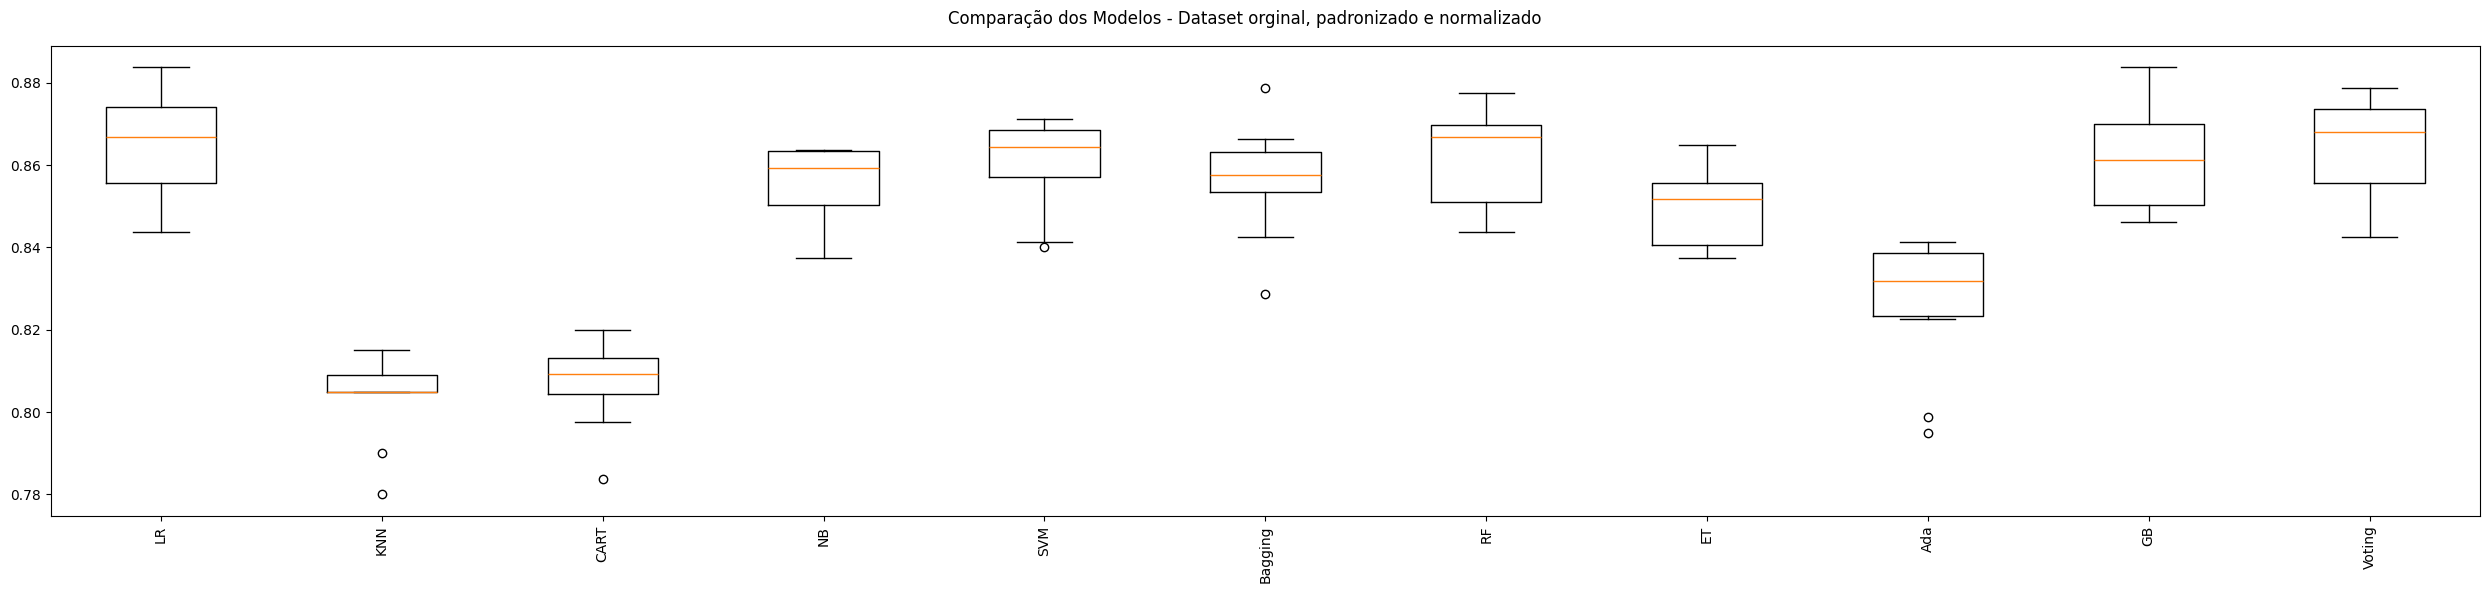

In [42]:
np.random.seed(42)

pipelines = []
results = []
names = []

reg_log = ('LR', LogisticRegression(max_iter=200))
knn = ('KNN', KNeighborsClassifier())
cart = ('CART', DecisionTreeClassifier())
naive_bayes = ('NB', GaussianNB())
svm = ('SVM', SVC())
bagging = ('Bag', BaggingClassifier(estimator=base, n_estimators=num_trees))
random_forest = ('RF', RandomForestClassifier(n_estimators=num_trees, max_features=max_features))
extra_trees = ('ET', ExtraTreesClassifier(n_estimators=num_trees, max_features=max_features))
adaboost = ('Ada', AdaBoostClassifier(n_estimators=num_trees))
gradient_boosting = ('GB', GradientBoostingClassifier(n_estimators=num_trees))
voting = ('Voting', VotingClassifier(bases))

standard_scaler = ('StandardScaler', StandardScaler())
min_max_scaler = ('MinMaxScaler', MinMaxScaler())

# Dataset original
pipelines.append(('LR-orig', Pipeline([reg_log])))
pipelines.append(('KNN-orig', Pipeline([knn])))
pipelines.append(('CART-orig', Pipeline([cart])))
pipelines.append(('NB-orig', Pipeline([naive_bayes])))
pipelines.append(('SVM-orig', Pipeline([svm])))
pipelines.append(('Bag-orig', Pipeline([bagging])))
pipelines.append(('RF-orig', Pipeline([random_forest])))
pipelines.append(('ET-orig', Pipeline([extra_trees])))
pipelines.append(('Ada-orig', Pipeline([adaboost])))
pipelines.append(('GB-orig', Pipeline([gradient_boosting])))
pipelines.append(('Vot-orig', Pipeline([voting])))

# Dataset Padronizado
pipelines.append(('LR-padr', Pipeline([standard_scaler, reg_log])))
pipelines.append(('KNN-padr', Pipeline([standard_scaler, knn])))
pipelines.append(('CART-padr', Pipeline([standard_scaler, cart])))
pipelines.append(('NB-padr', Pipeline([standard_scaler, naive_bayes])))
pipelines.append(('SVM-padr', Pipeline([standard_scaler, svm])))
pipelines.append(('Bag-padr', Pipeline([standard_scaler, bagging])))
pipelines.append(('RF-padr', Pipeline([standard_scaler, random_forest])))
pipelines.append(('ET-padr', Pipeline([standard_scaler, extra_trees])))
pipelines.append(('Ada-padr', Pipeline([standard_scaler, adaboost])))
pipelines.append(('GB-padr', Pipeline([standard_scaler, gradient_boosting])))
pipelines.append(('Vot-padr', Pipeline([standard_scaler, voting])))

# Dataset Normalizado
pipelines.append(('LR-norm', Pipeline([min_max_scaler, reg_log])))
pipelines.append(('KNN-norm', Pipeline([min_max_scaler, knn])))
pipelines.append(('CART-norm', Pipeline([min_max_scaler, cart])))
pipelines.append(('NB-norm', Pipeline([min_max_scaler, naive_bayes])))
pipelines.append(('SVM-norm', Pipeline([min_max_scaler, svm])))
pipelines.append(('Bag-norm', Pipeline([min_max_scaler, bagging])))
pipelines.append(('RF-norm', Pipeline([min_max_scaler, random_forest])))
pipelines.append(('ET-norm', Pipeline([min_max_scaler, extra_trees])))
pipelines.append(('Ada-norm', Pipeline([min_max_scaler, adaboost])))
pipelines.append(('GB-norm', Pipeline([min_max_scaler, gradient_boosting])))
pipelines.append(('Vot-norm', Pipeline([min_max_scaler, voting])))

# Executando os pipelines
for name, model in models:
    train_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Agora o cross_val_score recebe o PIPELINE, não o modelo isolado
    cv_results = cross_val_score(train_pipeline, X_train, y_train, cv=kfold, scoring=scoring)

    results.append(cv_results)
    names.append(name)

    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

# Boxplot de comparação dos modelos
fig = plt.figure(figsize=(25,6))
fig.suptitle('Comparação dos Modelos - Dataset orginal, padronizado e normalizado')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names, rotation=90)
plt.show()

## Otimização dos hiperparâmetros

In [43]:
np.random.seed(42)  # Definindo uma semente global para este bloco

# Lista de modelos
models = []

# Criando os modelos e adicionando-os na lista de modelos
models.append(('LR', LogisticRegression(max_iter=200)))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC()))

# Definindo os parâmetros do classificador base para o BaggingClassifier
base = DecisionTreeClassifier()
num_trees = 100
max_features = 3

# Criando os modelos para o VotingClassifier
bases = []
model1 = LogisticRegression(max_iter=200)
bases.append(('logistic', model1))
model2 = DecisionTreeClassifier()
bases.append(('cart', model2))
model3 = SVC()
bases.append(('svm', model3))

# Criando os ensembles e adicionando-os na lista de modelos
models.append(('Bagging', BaggingClassifier(estimator=base, n_estimators=num_trees)))
models.append(('RF', RandomForestClassifier(n_estimators=num_trees, max_features=max_features)))
models.append(('ET', ExtraTreesClassifier(n_estimators=num_trees, max_features=max_features)))
models.append(('Ada', AdaBoostClassifier(n_estimators=num_trees)))
models.append(('GB', GradientBoostingClassifier(n_estimators=num_trees)))
models.append(('Voting', VotingClassifier(estimators=bases, voting='hard')))

# Definindo os componentes do pipeline
standard_scaler = ('StandardScaler', StandardScaler())
min_max_scaler = ('MinMaxScaler', MinMaxScaler())

# Lista de pipelines
pipelines = []

# Criando pipelines para cada modelo
for name, model in models:
    pipelines.append((name + '-orig', Pipeline(steps=[(name, model)])))
    pipelines.append((name + '-padr', Pipeline(steps=[standard_scaler, (name, model)])))
    pipelines.append((name + '-norm', Pipeline(steps=[min_max_scaler, (name, model)])))

# Definindo os parâmetros para GridSearchCV
param_grids = {
    'LR': {
        'LR__C': [0.01, 0.1, 1, 10, 100],
        'LR__solver': ['liblinear', 'saga']
    },
    'KNN': {
        'KNN__n_neighbors': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21],
        'KNN__metric': ["euclidean", "manhattan", "minkowski"]
    },
    'CART': {
        'CART__max_depth': [None, 10, 20, 30, 40, 50],
        'CART__min_samples_split': [2, 5, 10],
        'CART__min_samples_leaf': [1, 2, 4]
    },
    'NB': {
        'NB__var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
    },
    'SVM': {
        'SVM__C': [0.1, 1, 10, 100],
        'SVM__gamma': [1, 0.1, 0.01, 0.001],
        'SVM__kernel': ['rbf', 'linear']
    },
    'RF': {
        'RF__n_estimators': [10, 50, 100, 200],
        'RF__max_features': ['auto', 'sqrt', 'log2'],
        'RF__max_depth': [None, 10, 20, 30],
        'RF__min_samples_split': [2, 5, 10],
        'RF__min_samples_leaf': [1, 2, 4]
    },
    'ET': {
        'ET__n_estimators': [10, 50, 100, 200],
        'ET__max_features': ['auto', 'sqrt', 'log2'],
        'ET__max_depth': [None, 10, 20, 30],
        'ET__min_samples_split': [2, 5, 10],
        'ET__min_samples_leaf': [1, 2, 4]
    },
    'Ada': {
        'Ada__n_estimators': [10, 50, 100, 200],
        'Ada__learning_rate': [0.01, 0.1, 1, 10]
    },
    'GB': {
        'GB__n_estimators': [10, 50, 100, 200],
        'GB__learning_rate': [0.01, 0.1, 0.2, 0.3],
        'GB__max_depth': [3, 5, 7, 9]
    },
    'Voting': {
        # Para VotingClassifier, geralmente não há hiperparâmetros para ajustar diretamente
        # Ajustar os hiperparâmetros dos estimadores base individualmente se necessário
    }
}

# Parâmetros de cross-validation e scoring
scoring = 'accuracy'
kfold = 5

pipelines_para_grid = []
for name, model in models:
    p = Pipeline(steps=[
        ('preprocessor', preprocessor),
        (name, model)
    ])
    pipelines_para_grid.append((name, p))

# 3. Execução do GridSearch
print("Iniciando otimização de hiperparâmetros...")

for name, pipeline in pipelines_para_grid:
    # Pega o dicionário de parâmetros correspondente ao nome do modelo (ex: 'LR')
    param_grid = param_grids.get(name, {})

    if not param_grid:
        print(f"Pulando {name}: Nenhum parâmetro definido em param_grids.")
        continue

    # Criando o GridSearchCV
    grid = GridSearchCV(estimator=pipeline, param_grid=param_grid, scoring=scoring, cv=kfold)

    # O X_train (com strings) entra aqui, o preprocessor trata, e o modelo recebe apenas números
    grid.fit(X_train, y_train)

    print("\nModelo: %s" % name)
    print("- Melhor Acurácia: %f" % grid.best_score_)
    print("- Melhores Parâmetros: %s" % grid.best_params_)

Iniciando otimização de hiperparâmetros...

Modelo: LR
- Melhor Acurácia: 0.865500
- Melhores Parâmetros: {'LR__C': 10, 'LR__solver': 'saga'}

Modelo: KNN
- Melhor Acurácia: 0.817625
- Melhores Parâmetros: {'KNN__metric': 'euclidean', 'KNN__n_neighbors': 15}

Modelo: CART
- Melhor Acurácia: 0.835875
- Melhores Parâmetros: {'CART__max_depth': 10, 'CART__min_samples_leaf': 2, 'CART__min_samples_split': 10}

Modelo: NB
- Melhor Acurácia: 0.853875
- Melhores Parâmetros: {'NB__var_smoothing': 1e-09}

Modelo: SVM
- Melhor Acurácia: 0.866125
- Melhores Parâmetros: {'SVM__C': 100, 'SVM__gamma': 1, 'SVM__kernel': 'linear'}
Pulando Bagging: Nenhum parâmetro definido em param_grids.

Modelo: RF
- Melhor Acurácia: 0.864625
- Melhores Parâmetros: {'RF__max_depth': 20, 'RF__max_features': 'log2', 'RF__min_samples_leaf': 2, 'RF__min_samples_split': 2, 'RF__n_estimators': 100}

Modelo: ET
- Melhor Acurácia: 0.862875
- Melhores Parâmetros: {'ET__max_depth': None, 'ET__max_features': 'log2', 'ET__min_sa

## Finalização do Modelo

In [51]:
np.random.seed(42)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(C=100, gamma=1, kernel='linear', probability=True))
])

pipeline.fit(X_train, y_train)

predictions = pipeline.predict(X_test)

print(f"Acurácia Final: {accuracy_score(y_test, predictions):.4f}")

Acurácia Final: 0.8690


### O valor 0.869 vem da validação cruzada no treino (estimativa), enquanto 0.858 é o desempenho real no conjunto de teste. Essa pequena diferença é normal e indica que o modelo generaliza bem, sem overfitting significativo.

In [45]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC())
])

pipeline.fit(X_train, y_train)

predictions = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predictions))

Accuracy: 0.8585


Rodando o modelo a partir de um pipeline com os hiperparâmetros otimizados.

In [52]:
np.random.seed(42)

model = SVC(C=100, gamma=1, kernel='linear', probability=True)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('SVM', model)
])

pipeline.fit(X_train, y_train)

predictions = pipeline.predict(X_test)

print(f"Acurácia Final: {accuracy_score(y_test, predictions):.4f}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, predictions))

Acurácia Final: 0.8690

Relatório de Classificação:
              precision    recall  f1-score   support

        High       0.88      0.89      0.88      1078
         Low       0.86      0.46      0.60        13
      Medium       0.86      0.85      0.86       909

    accuracy                           0.87      2000
   macro avg       0.86      0.73      0.78      2000
weighted avg       0.87      0.87      0.87      2000



# Simulando a aplicação do modelo em dados não vistos

O SVM destacou-se por sua capacidade de criar hiperplanos de separação complexos em espaços de alta dimensão (especialmente útil após o uso de One-Hot Encoding e as novas variáveis de Feature Engineering).

- Robustez: Ele lidou bem com a natureza mista dos dados (categóricos e numéricos).
- Ponto de Atenção (Classe Low): O modelo obteve $0.00$ de F1-Score na categoria Low. Isso ocorre porque o seu dataset possui pouquíssimos exemplos desta classe (apenas 13 no teste), fazendo com que o modelo priorize as classes majoritárias (High e Medium) para maximizar a acurácia global.

In [54]:
pipeline_final = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('SVM', SVC(C=100, gamma=1, kernel='linear', probability=True))
])

pipeline_final.fit(X, y)

print("Modelo final treinado com sucesso e pronto para predições!")

Modelo final treinado com sucesso e pronto para predições!


In [55]:
df_original.head()

,Age,Gender,Student_Working_Status,Daily_Social_Media_Hours,Screen_Time_Hours,Night_Scrolling_Frequency,Online_Gaming_Hours,Content_Type_Preference,Exercise_Frequency_per_Week,Daily_Sleep_Hours,Caffeine_Intake_Cups,Study_Work_Hours_per_Day,Overthinking_Score,Anxiety_Score,Mood_Stability_Score,Social_Comparison_Index,Sleep_Quality_Score,Motivation_Level,Emotional_Fatigue_Score,Wellbeing_Index,Burnout_Risk,Sleep_Efficiency,Screen_Time_Ratio,Wellbeing_Balance
0,24,Male,Working,4.81,6.93,2.61,2.07,News,5.41,6.84,1.52,11.42,4.95,4.13,5.74,4.67,6.27,6.13,6.45,4.28,Medium,0.799745,0.403846,-0.32
1,21,Male,Student,4.16,7.94,1.85,3.58,Gaming,3.41,7.88,2.23,6.98,5.91,3.63,5.75,5.38,7.37,6.27,3.74,5.23,Medium,0.829955,0.492556,2.53
2,25,Male,Student,3.07,7.45,2.96,2.85,Entertainment,3.40,6.39,0.53,7.79,4.06,5.67,6.03,2.41,6.48,4.82,6.69,3.72,High,0.876861,0.423055,-1.87
3,22,Female,Student,4.41,7.34,4.51,3.37,Educational,2.19,7.92,0.58,6.61,6.10,4.78,4.85,5.86,7.27,5.17,5.96,3.97,High,0.815022,0.456468,-0.79
4,24,Male,Student,2.97,5.76,2.36,1.77,Educational,4.93,5.97,1.64,4.81,5.22,4.23,5.05,5.54,6.34,5.72,2.22,4.63,Medium,0.909613,0.319468,3.50


In [56]:
import random

generos = ['Male', 'Female', 'Non-binary']
status = ['Student', 'Working', 'Both']
preferencias = ['Entertainment', 'Educational', 'News', 'Gaming', 'Lifestyle']

print(f"{'#'*10} Iniciando Simulação com Dados Aleatórios {'#'*10}\n")

n_testes = 30

for i in range(n_testes):
    idade = random.randint(18, 26)
    genero = random.choice(generos)
    situacao = random.choice(status)
    preferencia = random.choice(preferencias)

    sono = random.randint(4, 10)
    telas = random.randint(2, 14)

    qualidade_sono = random.randint(1, 10)
    motivacao = random.randint(1, 10)
    fadiga = random.randint(1, 10)

    caso_dict = {
        'Age': idade,
        'Gender': genero,
        'Student_Working_Status': situacao,
        'Daily_Sleep_Hours': sono,
        'Screen_Time_Hours': telas,
        'Sleep_Quality_Score': qualidade_sono,
        'Motivation_Level': motivacao,
        'Emotional_Fatigue_Score': fadiga,
        'Content_Type_Preference': preferencia
    }

    df_input = pd.DataFrame([caso_dict])

    df_input['Sleep_Efficiency'] = df_input['Sleep_Quality_Score'] / (df_input['Daily_Sleep_Hours'] + 1)
    df_input['Screen_Time_Ratio'] = df_input['Screen_Time_Hours'] / (24 - df_input['Daily_Sleep_Hours'])
    df_input['Wellbeing_Balance'] = df_input['Motivation_Level'] - df_input['Emotional_Fatigue_Score']

    predicao = pipeline_final.predict(df_input)[0]
    probabilidades = pipeline_final.predict_proba(df_input)[0]
    confianca = max(probabilidades) * 100

    print(f"Teste {i+1}:")
    print(f"  [ENTRADAS] {genero}, {idade} anos, {situacao}")
    print(f"             Sono: {sono}h (Qualidade: {qualidade_sono}/10)")
    print(f"             Telas: {telas}h | Saldo Emocional: {df_input['Wellbeing_Balance'].values[0]}")
    print(f"  [RESULTADO] Risco de Burnout: **{predicao}**")
    print(f"  [CONFIANÇA] {confianca:.2f}%")
    print("-" * 50)

########## Iniciando Simulação com Dados Aleatórios ##########

Teste 1:
  [ENTRADAS] Female, 26 anos, Both
             Sono: 9h (Qualidade: 5/10)
             Telas: 6h | Saldo Emocional: -3
  [RESULTADO] Risco de Burnout: **High**
  [CONFIANÇA] 96.35%
--------------------------------------------------
Teste 2:
  [ENTRADAS] Male, 19 anos, Both
             Sono: 5h (Qualidade: 8/10)
             Telas: 5h | Saldo Emocional: 8
  [RESULTADO] Risco de Burnout: **Low**
  [CONFIANÇA] 75.30%
--------------------------------------------------
Teste 3:
  [ENTRADAS] Non-binary, 20 anos, Working
             Sono: 7h (Qualidade: 1/10)
             Telas: 6h | Saldo Emocional: 0
  [RESULTADO] Risco de Burnout: **High**
  [CONFIANÇA] 99.70%
--------------------------------------------------
Teste 4:
  [ENTRADAS] Non-binary, 26 anos, Working
             Sono: 10h (Qualidade: 7/10)
             Telas: 10h | Saldo Emocional: 7
  [RESULTADO] Risco de Burnout: **Medium**
  [CONFIANÇA] 66.94%
-------

# Salvando os Dados

In [57]:
dirs = {
    "models": "../models",
    "scalers": "../scalers",
    "pipelines": "../pipelines",
    "data": "../data"
}

# Criar diretórios se não existirem
for path in dirs.values():
    os.makedirs(path, exist_ok=True)

# Salvando o modelo
model_filename = os.path.join(dirs["models"], "svm_gen_z_classifier.pkl")
with open(model_filename, 'wb') as file:
    cloudpickle.dump(model, file)

# Salvando o pipeline (recomendado)
pipeline_filename = os.path.join(dirs["pipelines"], "svm_gen_z_pipeline.pkl")
with open(pipeline_filename, 'wb') as file:
    cloudpickle.dump(pipeline_final, file)

# Salvando dataset completo (df_copy)
df_copy.to_csv(
    os.path.join(dirs["data"], "gen_z_full_dataset.csv"),
    index=False
)

# Salvando X_test e y_test
df_data = df_copy.copy()
X_test_df = pd.DataFrame(X_test, columns=X.columns)
y_test_df = pd.DataFrame(y_test, columns=["Burnout_Risk"])

X_test_df.to_csv(os.path.join(dirs["data"], "X_test_dataset_gen_z.csv"), index=False)
y_test_df.to_csv(os.path.join(dirs["data"], "y_test_dataset_gen_z.csv"), index=False)